In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### read data


In [2]:
sal_data = pd.read_csv(r"D:\ML Project1\emp sal pred lm\Dataset09-Employee-salary-prediction.csv")
sal_data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
sal_data.shape

(375, 6)

In [4]:
sal_data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [5]:
# renaming columns
sal_data.columns = ['Age','Gender','Degree','Job_Title','Experience_years','Salary']

In [6]:
sal_data.head()

,Age,Gender,Degree,Job_Title,Experience_years,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [7]:
sal_data.dtypes

Age                 float64
Gender               object
Degree               object
Job_Title            object
Experience_years    float64
Salary              float64
dtype: object

In [8]:
# checking null
sal_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               373 non-null    float64
 1   Gender            373 non-null    object 
 2   Degree            373 non-null    object 
 3   Job_Title         373 non-null    object 
 4   Experience_years  373 non-null    float64
 5   Salary            373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [9]:
# checking duplicate
sal_data[sal_data.duplicated()]

,Age,Gender,Degree,Job_Title,Experience_years,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
254,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
255,44.0,Male,Bachelor's,Senior Software Engineer,14.0,130000.0
256,34.0,Female,Master's,Senior Financial Advisor,6.0,100000.0
257,35.0,Male,Bachelor's,Senior Project Coordinator,9.0,95000.0
258,50.0,Female,PhD,Director of Operations,22.0,180000.0


In [10]:
# drop duplicate
sal_data1 = sal_data.drop_duplicates(keep='first')

In [11]:
# null values in each column
sal_data1.isnull().sum()

Age                 1
Gender              1
Degree              1
Job_Title           1
Experience_years    1
Salary              1
dtype: int64

In [12]:
# droping missing value
sal_data1.dropna(how='any',inplace=True)

C:\Users\Aviral Goyal\AppData\Local\Temp\ipykernel_17952\2513663517.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal_data1.dropna(how='any',inplace=True)


In [13]:
sal_data1.shape

(324, 6)

In [14]:
# stats of numerical coloumn:
sal_data1.describe()

,Age,Experience_years,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [15]:
# Correlation matrix amoung numerical features:
corr = sal_data1[['Age','Experience_years','Salary']].corr()
corr

,Age,Experience_years,Salary
Age,1.000000,0.979192,0.916543
Experience_years,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


<Axes: >

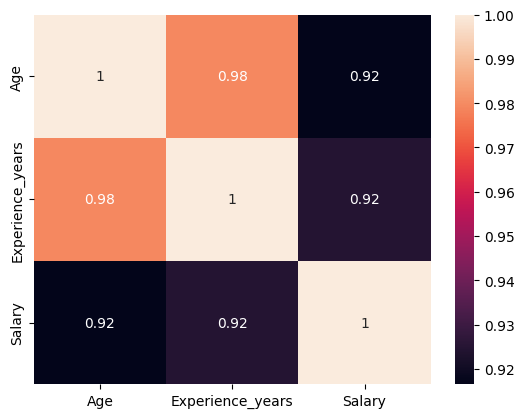

In [16]:
sns.heatmap(corr,annot=True)

In [17]:
# Data Visualization

In [18]:
sal_data1['Degree'].value_counts()

Degree
Bachelor's    191
Master's       91
PhD            42
Name: count, dtype: int64

<Axes: xlabel='Degree'>

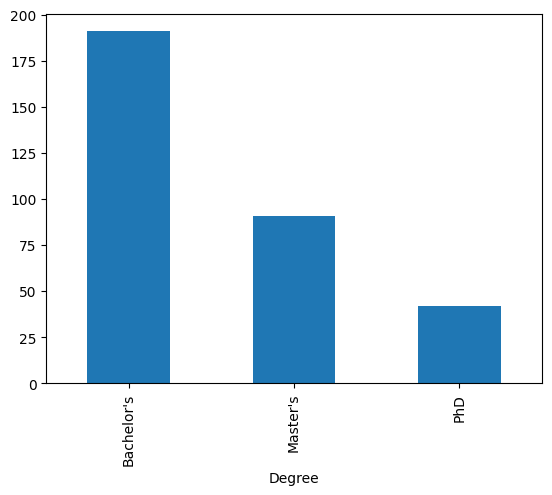

In [19]:
sal_data1['Degree'].value_counts().plot(kind='bar')

In [20]:
sal_data1['Job_Title'].value_counts()

Job_Title
Director of Operations            9
Director of Marketing             8
Senior Marketing Manager          8
Senior Project Manager            7
Senior Data Scientist             6
                                 ..
Junior Social Media Specialist    1
Junior Operations Coordinator     1
Senior HR Specialist              1
Director of HR                    1
Junior Financial Advisor          1
Name: count, Length: 174, dtype: int64

<Axes: ylabel='Job_Title'>

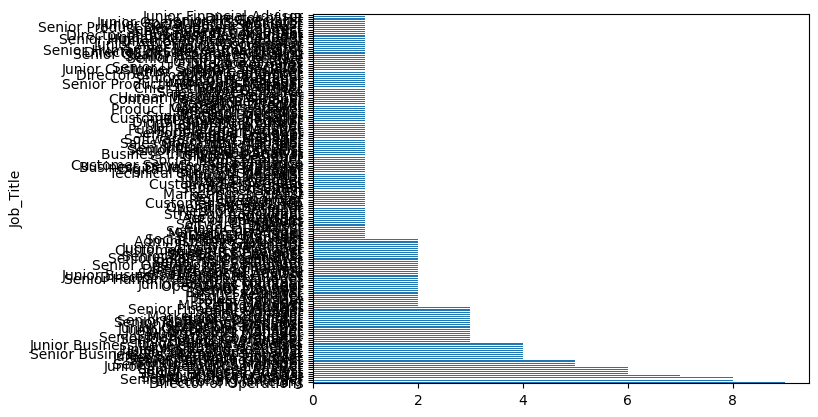

In [21]:
sal_data1['Job_Title'].value_counts().plot(kind='barh')
# 174 unique values graph possible but no sense

<Axes: ylabel='Gender'>

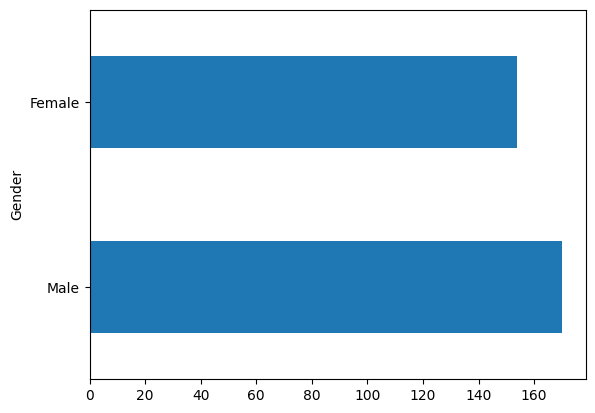

In [22]:
sal_data1['Gender'].value_counts().plot(kind='barh')

### Numerical Values - Histogram / Box plot

<Axes: ylabel='Frequency'>

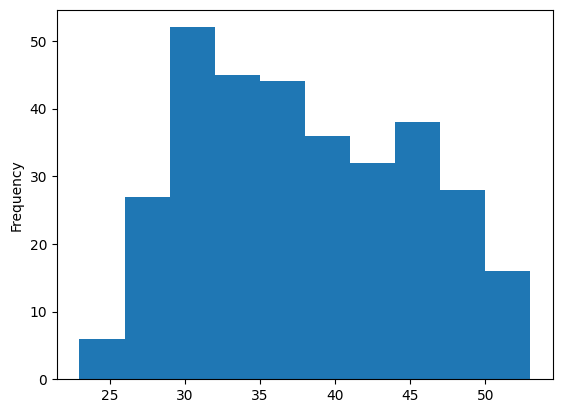

In [23]:
sal_data1.Age.plot(kind='hist')

<Axes: >

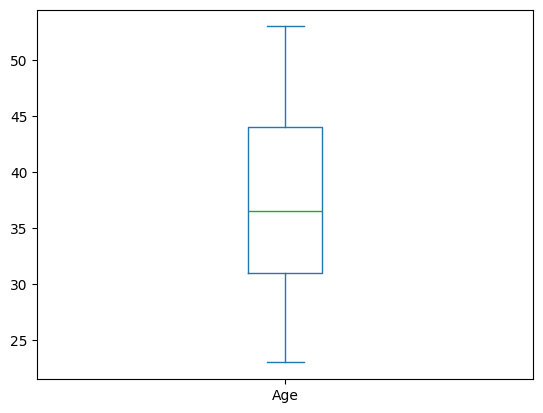

In [24]:
sal_data1.Age.plot(kind='box')

<Axes: ylabel='Frequency'>

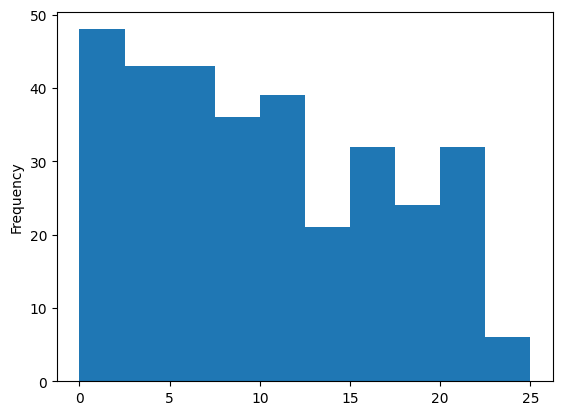

In [25]:
sal_data1.Experience_years.plot(kind='hist')

<Axes: >

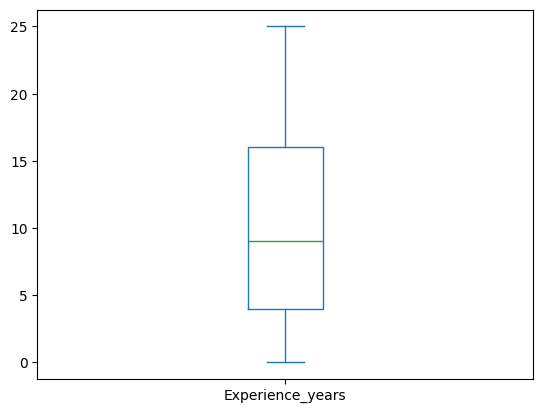

In [26]:
sal_data1.Experience_years.plot(kind='box')

# Feature Eng

## Lable Encoding

In [27]:
from sklearn.preprocessing import LabelEncoder
Label_Encoder = LabelEncoder()

In [28]:
sal_data1['Gender_Encode'] = Label_Encoder.fit_transform(sal_data1['Gender'])

C:\Users\Aviral Goyal\AppData\Local\Temp\ipykernel_17952\1017469824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal_data1['Gender_Encode'] = Label_Encoder.fit_transform(sal_data1['Gender'])


In [29]:
sal_data1['Degree_Encode'] = Label_Encoder.fit_transform(sal_data1['Degree'])

C:\Users\Aviral Goyal\AppData\Local\Temp\ipykernel_17952\446779904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal_data1['Degree_Encode'] = Label_Encoder.fit_transform(sal_data1['Degree'])


In [30]:
sal_data1['Job_Title_Encode'] = Label_Encoder.fit_transform(sal_data1['Job_Title'])

C:\Users\Aviral Goyal\AppData\Local\Temp\ipykernel_17952\840262182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal_data1['Job_Title_Encode'] = Label_Encoder.fit_transform(sal_data1['Job_Title'])


In [31]:
sal_data1

,Age,Gender,Degree,Job_Title,Experience_years,Salary,Gender_Encode,Degree_Encode,Job_Title_Encode
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22
...,...,...,...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0,0,0,68
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0,1,0,111
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0,0,2,115
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0,1,0,63


## Feature Scalling

In [32]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [33]:
sal_data1['Age_scaled'] = std_scaler.fit_transform(sal_data1[['Age']])
sal_data1['Experience_years_scaled'] = std_scaler.fit_transform(sal_data1[['Experience_years']])

C:\Users\Aviral Goyal\AppData\Local\Temp\ipykernel_17952\2823734138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal_data1['Age_scaled'] = std_scaler.fit_transform(sal_data1[['Age']])
C:\Users\Aviral Goyal\AppData\Local\Temp\ipykernel_17952\2823734138.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sal_data1['Experience_years_scaled'] = std_scaler.fit_transform(sal_data1[['Experience_years']])


In [34]:
sal_data1.head()

,Age,Gender,Degree,Job_Title,Experience_years,Salary,Gender_Encode,Degree_Encode,Job_Title_Encode,Age_scaled,Experience_years_scaled
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159,-0.750231,-0.761821
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17,-1.307742,-1.063017
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130,1.061680,0.744158
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101,-0.192720,-0.460625
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22,2.037324,1.497148


In [35]:
# Dependent and Independent Variable:
X = sal_data1[['Age_scaled','Gender_Encode','Degree_Encode','Job_Title_Encode','Experience_years_scaled']]
y = sal_data1['Salary']

In [36]:
# Spliting data into test and train :
from sklearn.model_selection import train_test_split

In [37]:
X_train , X_test , y_train , y_test = train_test_split(X ,y , test_size= 0.2 ,random_state= 42)

In [38]:
X_train.head()

,Age_scaled,Gender_Encode,Degree_Encode,Job_Title_Encode,Experience_years_scaled
73,-1.307742,1,0,166,-1.213615
182,0.922302,0,2,155,0.744158
17,0.225413,1,2,116,0.292364
24,0.504169,1,1,37,0.442962
146,0.643547,0,2,115,0.894756


In [39]:
# MOdel devlopment

In [40]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
y_pred_lr = lm.predict(X_test)
y_pred_lr

array([117415.91344602, 125562.80742758,  48965.15386167, 128739.34887988,
       106828.49930535,  99654.76748821,  49101.27883652,  57130.71108104,
       166333.69009266,  43112.61060113,  40544.18249367, 122553.217185  ,
       107631.15450848, 155580.48335296,  83652.23602446, 170890.28450907,
        98984.50106226, 109338.33008328,  42267.86835535,  48089.87647812,
        75674.93528581,  64499.29874156,  63619.2494321 ,  31543.41552147,
       188376.92844437,  90340.76921722, 155285.91529198, 160863.57809872,
       185183.73163709,  34741.26224478, 124850.6230462 , 165106.94121635,
        87085.00622186, 155425.69514031, 149190.25441885,  45729.74800187,
        88475.39474629,  92025.62668073,  97997.32557607,  40411.112659  ,
        89995.79796521,  53873.21977084, 108677.48549927,  54590.96778663,
        36497.92729223,  48611.85493217, 129193.72126941,  43102.58902589,
       162383.16672117,  81874.95829259, 157771.0301154 ,  43984.89040816,
        59950.21740617,  

In [42]:
df = pd.DataFrame({'y_Actual': y_test , 'y_predicted' : y_pred_lr})
df['Error'] = df['y_Actual'] - df['y_predicted']
df['abs_error'] = abs(df['Error'])
Mean_absolute_error = df['abs_error'].mean()
Mean_absolute_error

np.float64(10570.78640113616)

In [43]:
# Model Evaluation
from sklearn.metrics import accuracy_score , r2_score
from sklearn.metrics import mean_squared_error , mean_absolute_error

In [ ]:
# Model accuracy
r2_score(y_test , y_pred_lr)

0.8911231066517091

In [45]:
print(f'Accuracy of the Model = {round(r2_score(y_test , y_pred_lr),4)*100}%')

Accuracy of the Model = 89.11%


In [47]:
# Mean Absolute Error
round(mean_absolute_error(y_test , y_pred_lr),2)
print(f'Mean Absolute Error : {round(mean_absolute_error(y_test , y_pred_lr),2)}')

Mean Absolute Error : 10570.79


In [48]:
# Mean Squared Error
mse = round(mean_squared_error(y_test , y_pred_lr),2)
print(f"Mean Squared Error :{mse}")

Mean Squared Error :205754135.72


In [53]:
# Root Mean Squared Error
print('Root Mean Squared Error (RMSE) =',mse**0.5)

Root Mean Squared Error (RMSE) = 14344.132449193294


In [54]:
# coefficient:
lm.coef_

array([2.01818940e+04, 7.38907834e+03, 1.54227359e+04, 1.95769562e+01,
       1.92043082e+04])

In [55]:
#intercept
lm.intercept_

np.float64(86001.49320553176)

## Customized Prediction

In [62]:
Age1 = std_scaler.transform([[49]])
Age1
Experience_year1 = std_scaler.transform([[15]])
Experience_year1

c:\Users\Aviral Goyal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Aviral Goyal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.74415815]])

In [63]:
Age = 5.86448677
Gender = 0
Degree = 2
Job_Title = 22
Experience_year = 0.74415815

In [64]:
Emp_salary = lm.predict([[Age,Gender,Degree,Job_Title,Experience_year]])
Emp_salary

c:\Users\Aviral Goyal\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([249925.15061728])

In [66]:
print("Employ`s Predicted Salary:",Emp_salary[0])

Employ`s Predicted Salary: 249925.15061727568
